# 1. Global mCH

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{outdir}clustering/merged/L1pre/5kCG_lsi.h5ad'`  ·  _raw embedding_
- `f'{outdir}clustering/merged/L1/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}merged/ALL_lambda.csv.gz'`  ·  _lambda control_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.integration.seurat_class import SeuratIntegration

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = '/data/ENTEx/'
outdir = '/mnt/disks/jupyter/home/jzhou_salk_edu/sky_workdir/ENTEx/'


In [8]:
tmp = anndata.read_h5ad(f'{outdir}clustering/merged/L1pre/5kCG_lsi.h5ad')
tmp


/opt/conda/envs/analysis/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 86689 × 0
    obs: 'batch', 'Plate', 'PCRIndex', 'MultiplexGroup', 'RandomIndex', 'Col384', 'Row384', 'R1InputReads', 'R1InputReadsBP', 'R1WithAdapters', 'R1QualTrimBP', 'R1TrimmedReads', 'R1TrimmedReadsBP', 'R1TrimmedReadsRate', 'R1UniqueMappedReads', 'R1DeduppedReads', 'R2InputReads', 'R2InputReadsBP', 'R2WithAdapters', 'R2QualTrimBP', 'R2TrimmedReads', 'R2TrimmedReadsBP', 'R2TrimmedReadsRate', 'R2UniqueMappedReads', 'R2DeduppedReads', 'CisShortContact', 'CisLongContact', 'TransContact', 'mCHmC', 'mCHCov', 'mCHFrac', 'mCGmC', 'mCGCov', 'mCGFrac', 'mCCCmC', 'mCCCCov', 'mCCCFrac', 'GenomeCov', 'FinalmCReads', 'CellInputReadPairs', 'R1MappingRate', 'R2MappingRate', 'R1DuplicationRate', 'R2DuplicationRate', 'CellBarcodeRatio', 'TotalContacts', 'CisShortRatio', 'CisLongRatio', 'TransRatio', 'Pool', 'Tissue', 'Sample', 'Donor', 'Protocol', 'Cis/Trans', 'tsne_0', 'tsne_1', 'Cluster', 'ClusterTissue', 'leiden', '5kCG_u50hm_leiden_0.5', '5kCG_u50hm_leiden_

In [4]:
adata = anndata.read_h5ad(f'{outdir}clustering/merged/L1/5kCG100k3C_embed.h5ad')
adata


/opt/conda/envs/analysis/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 86689 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'L1'
    obsm: '5kCG100k3C_u50pc50', '5kCG100k3C_u50pc50_tsne', 'X_tsne'

In [5]:
lam = pd.read_csv(f'{indir}merged/ALL_lambda.csv.gz', header=0, index_col=0)
lam

,mc,cov,ratio
cell,,,
AG_JF1NQ_AR_Plate10-1-I15-A13,1663,273311,0.006085
AG_JF1NQ_AR_Plate10-1-I15-A14,2495,390789,0.006385
AG_JF1NQ_AR_Plate10-1-I15-A1,1943,404006,0.004809
AG_JF1NQ_AR_Plate10-1-I15-A2,1573,284916,0.005521
AG_JF1NQ_AR_Plate10-1-I15-B13,1938,356929,0.005430
...,...,...,...
TrCo_A9VP4_Plate8-6-J5-O24,0,10,0.000000
TrCo_A9VP4_Plate8-6-J5-P11,2,115,0.017391
TrCo_A9VP4_Plate8-6-J5-P12,2,479,0.004175


In [11]:
meta.groupby('Tissue')['cov'].mean().sort_values()

Tissue
LG           42.124317
Sk           69.026878
EG           92.588166
ST          139.705450
SkGcn       167.999282
TrCo        177.609836
M1C         188.945653
B           268.943952
NTb         293.576543
PBMC        294.667301
SB         1794.870558
LV       156774.371775
RAA      183522.280091
P        367416.452626
AG       499903.707733
PI       689529.581702
Name: cov, dtype: float64

In [12]:
leg = np.sort(meta['Tissue'].unique())
leg

array(['AG', 'B', 'EG', 'LG', 'LV', 'M1C', 'NTb', 'P', 'PBMC', 'PI',
       'RAA', 'SB', 'ST', 'Sk', 'SkGcn', 'TrCo'], dtype=object)

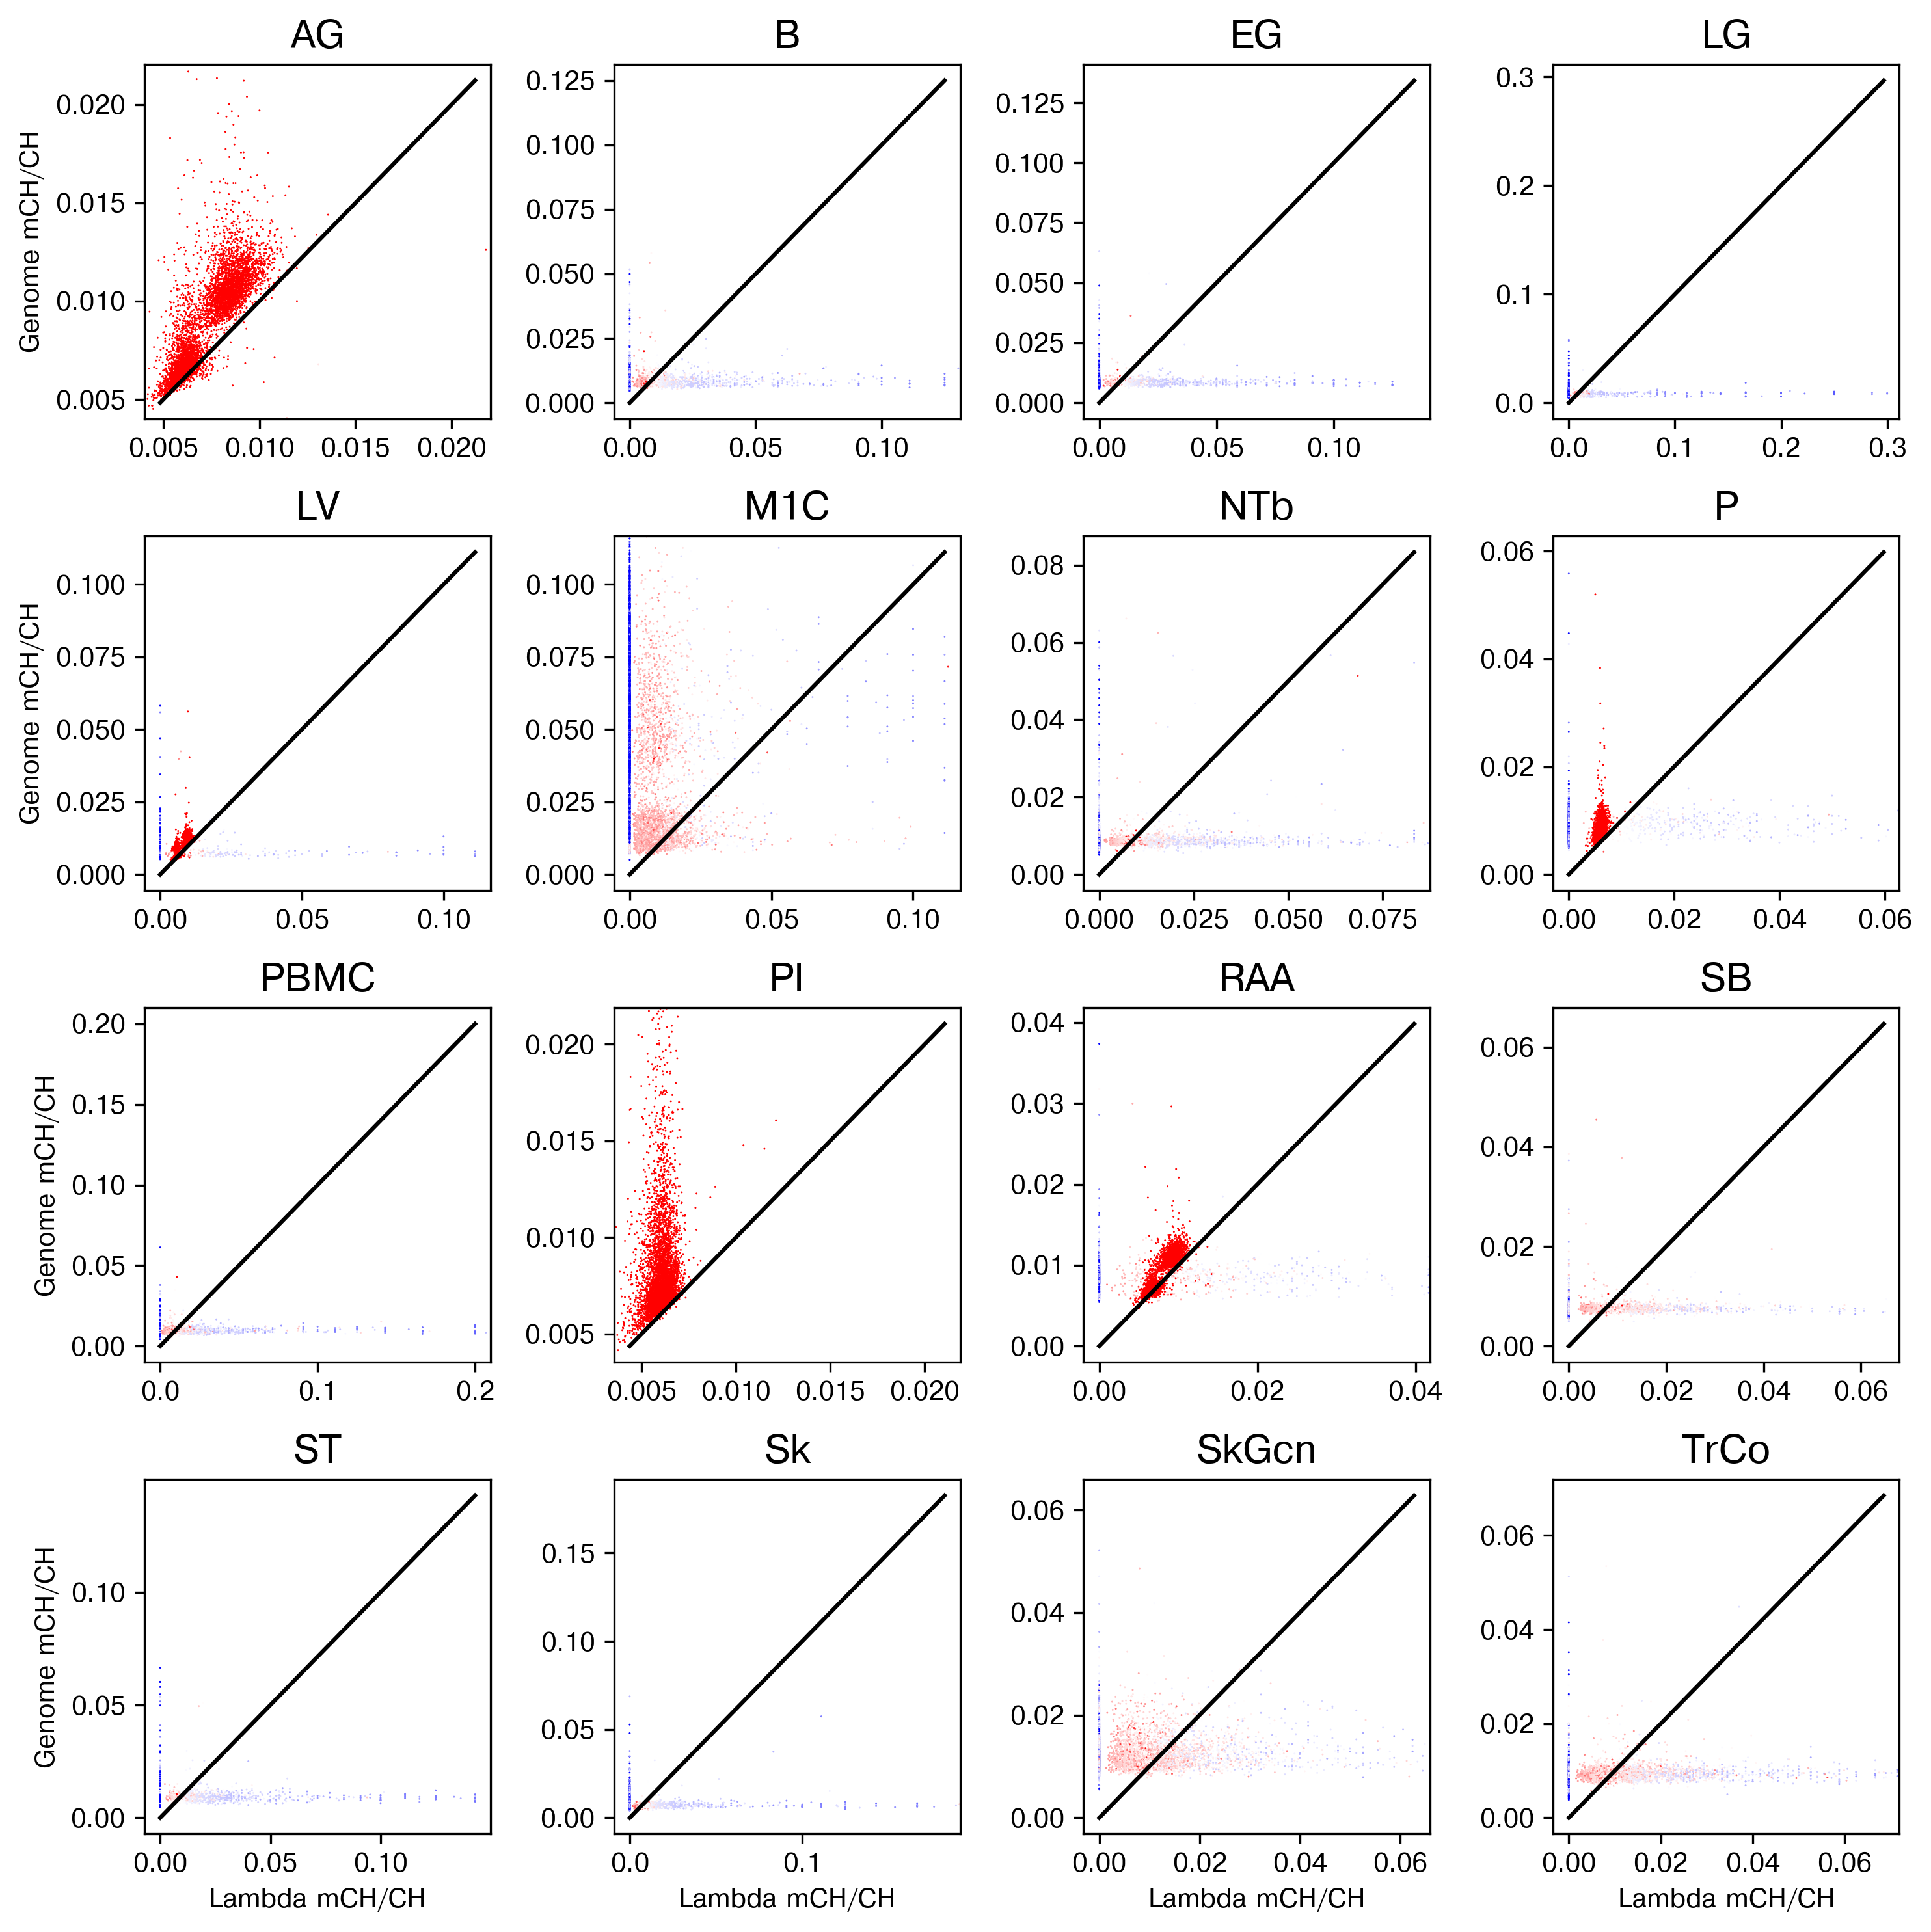

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10), dpi=300)
for xx,ax in zip(leg, axes.flatten()):
    tmp = meta.loc[(meta['Tissue']==xx)]

    # selc = (tmp['cov']>100)
    # ax.scatter(tmp.loc[selc, 'ratio'], tmp.loc[selc, 'mCHFrac'], c='C0', s=0.5, edgecolor='none')
    # ax.scatter(tmp.loc[~selc, 'ratio'], tmp.loc[~selc, 'mCHFrac'], c='C1', s=0.5, edgecolor='none')
    cov = np.log10(tmp['cov']+1)
    # cov[cov>np.percentile(cov, 99)] = np.percentile(cov, 99)
    # cov[cov<np.percentile(cov, 1)] = np.percentile(cov, 1)
    
    ax.scatter(tmp['ratio'], tmp['mCHFrac'], c=cov, cmap='bwr', s=0.5, 
               vmin=0, vmax=4, edgecolor='none')
    
    # xlim, ylim = np.percentile(tmp['ratio'], [1,99]), np.percentile(tmp['mCCCFrac'], [1,99]) 
    # ax.set_xlim([xlim[0]-0.001, xlim[1]+0.001])
    # ax.set_ylim([ylim[0]-0.001, ylim[1]+0.001])
    lim = [min([np.percentile(tmp['ratio'], 1), np.percentile(tmp['mCHFrac'], 1)]), 
           max([np.percentile(tmp['ratio'], 99), np.percentile(tmp['mCHFrac'], 99)])]
    diff = 0.05*(lim[1]-lim[0])
    ax.set_xlim([lim[0]-diff, lim[1]+diff])
    ax.set_ylim([lim[0]-diff, lim[1]+diff])
    ax.plot(lim, lim, c='k')
    ax.set_title(xx, fontsize=15)

for ax in axes[:,0]:
    ax.set_ylabel('Genome mCH/CH')

for ax in axes[-1]:
    ax.set_xlabel('Lambda mCH/CH')

plt.tight_layout()


In [10]:
selcol = ['Tissue', 'Sample', 'Donor', 
          'Cis/Trans', 'CisLongContact', 'FinalmCReads', 
          'mCHmC', 'mCHCov', 'mCHFrac', 
          'mCGmC', 'mCGCov', 'mCGFrac', 
          'mCCCmC', 'mCCCCov', 'mCCCFrac']
meta = pd.concat([tmp.obs.loc[adata.obs.index, selcol], lam.loc[adata.obs.index]], axis=1)
meta['L1'] = adata.obs['L1'].copy() 
meta

,Tissue,Sample,Donor,Cis/Trans,CisLongContact,FinalmCReads,mCHmC,mCHCov,mCHFrac,mCGmC,mCGCov,mCGFrac,mCCCmC,mCCCCov,mCCCFrac,mc,cov,ratio,L1
cell,,,,,,,,,,,,,,,,,,,
M1C_3C_001_Plate1-1-F3-A2,M1C,M1CA1,H1930001,1.214015,312428,3090972,777325,52698636,0.014750,2045762.0,2684541.0,0.762053,28183,3694583,0.007628,0,50,0.000000,Glia Oligo
M1C_3C_001_Plate1-1-F3-B1,M1C,M1CA1,H1930001,1.371837,204069,1995864,744272,33201595,0.022417,1336204.0,1720789.0,0.776507,22448,2248596,0.009983,2,92,0.021739,Glia Oligo
M1C_3C_001_Plate1-1-F3-B13,M1C,M1CA1,H1930001,1.243364,550768,4906103,1134907,85148312,0.013329,3256105.0,4484117.0,0.726142,45457,6032379,0.007536,1,216,0.004630,Hema Myeloid
M1C_3C_001_Plate1-1-F3-B14,M1C,M1CA1,H1930001,1.962490,452876,3369702,2431679,57446221,0.042330,2251533.0,2971885.0,0.757611,45682,4024233,0.011352,0,109,0.000000,Neu Exc
M1C_3C_001_Plate1-1-F3-B2,M1C,M1CA1,H1930001,1.774154,589374,4373711,3203879,74285514,0.043129,2949948.0,3858604.0,0.764512,56451,5231765,0.010790,2,137,0.014599,Neu Exc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sk_IOBHT_AR_Plate7-6-I24-O12,Sk,IOBHT,PT-1LGRB,1.088724,186861,2276509,284305,40938406,0.006945,1519210.0,2111557.0,0.719474,15052,2935733,0.005127,0,0,0.000000,Fibro Sk
Sk_IOBHT_AR_Plate7-6-I24-O23,Sk,IOBHT,PT-1LGRB,1.178620,326579,3279874,363886,56020850,0.006496,1943298.0,2762732.0,0.703397,19899,3943177,0.005046,5,854,0.005855,Fibro Sk
Sk_IOBHT_AR_Plate7-6-I24-O24,Sk,IOBHT,PT-1LGRB,1.132499,244117,2692787,310511,46461072,0.006683,1691133.0,2362033.0,0.715965,16541,3336383,0.004958,0,0,0.000000,Fibro Sk


In [14]:
mch_df = meta.groupby('L1')[['mCHmC', 'mCHCov', 'mc', 'cov']].sum()
mch_df['LambdamCHFrac'] = mch_df['mc'] / mch_df['cov']
mch_df['BulkmCHFrac'] = mch_df['mCHmC'] / mch_df['mCHCov']
mch_df['AvemCHFrac'] = meta.groupby('L1')['mCHFrac'].mean()
mch_df.sort_values('AvemCHFrac') 

,mCHmC,mCHCov,mc,cov,LambdamCHFrac,BulkmCHFrac,AvemCHFrac
L1,,,,,,,
Epi Duc,187825752,26511367724,3031104,503382119,0.006021,0.007085,0.007072
Epi Aci,360726051,49176470203,5761649,954716955,0.006035,0.007335,0.007287
Epi Krt/Lum,554831733,74623341103,1891,261969,0.007218,0.007435,0.007396
Fibro Sk,457629775,60372946529,730,72530,0.010065,0.007580,0.007521
Endo Lym,191128659,23172920205,138237,19935942,0.006934,0.008248,0.008219
Epi Alv,525614691,63266863730,327,31856,0.010265,0.008308,0.008303
Hema Tmem,2808623481,336063154366,977690,129317675,0.007560,0.008357,0.008312
Hema Mast,420162729,49521406189,29112,3659490,0.007955,0.008484,0.008514
Hema B,1318449000,153468228572,52105,6830014,0.007629,0.008591,0.008586


In [105]:
from scipy.stats import binom
[binom.sf(m-1,n,p) for m,n,p in mch_df[['mCHmC', 'mCHCov', 'LambdamCHFrac']].values]

[0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

/var/tmp/ipykernel_35588/3669204204.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(yy[0], yy[1], label=xx, c=colordict[xx], s=20, edgecolor='none')
/var/tmp/ipykernel_35588/3669204204.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(yy[0], yy[1], label=xx, c=colordict[xx], s=20, edgecolor='none')


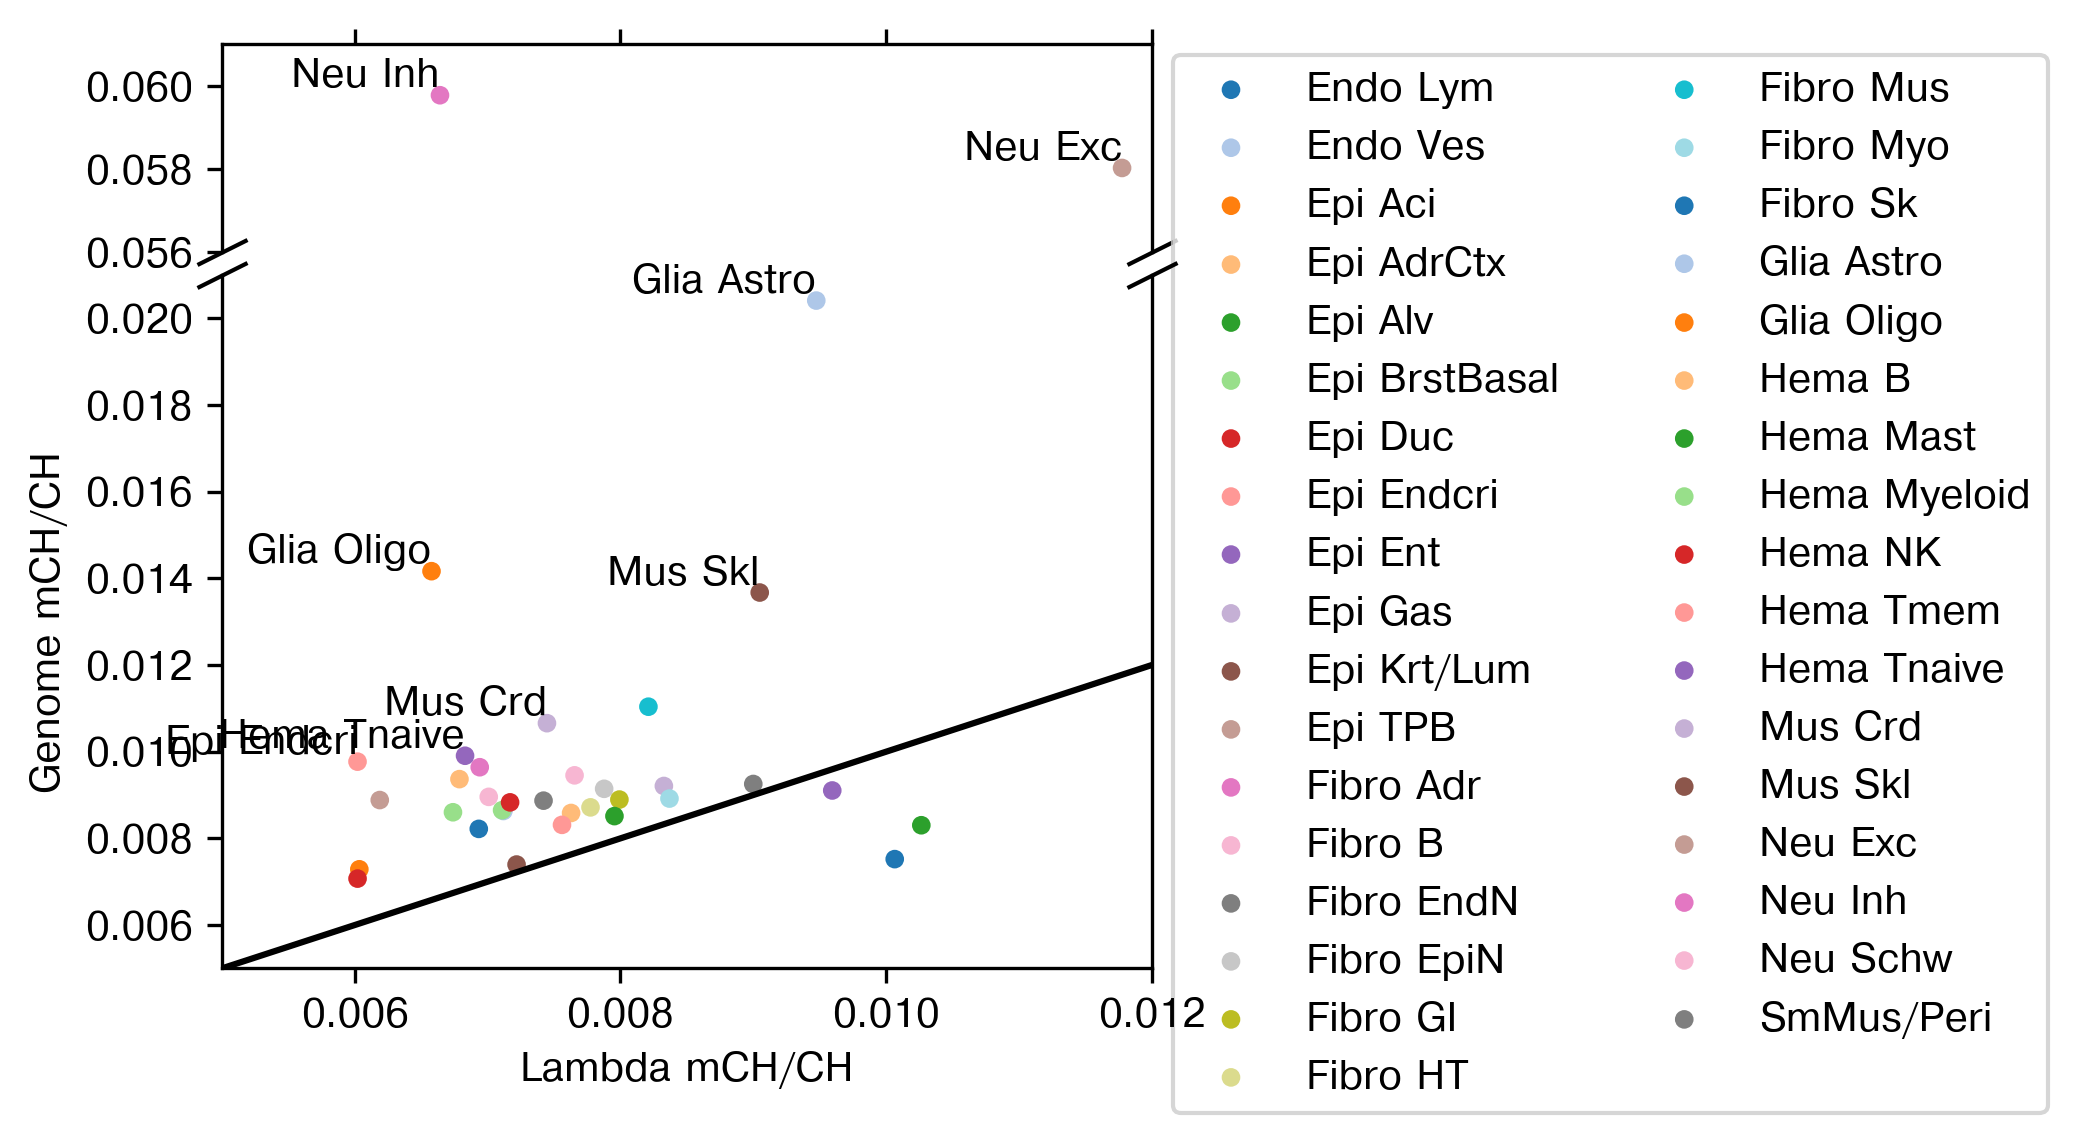

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(4,4), sharex=True, 
                         gridspec_kw={'height_ratios': [0.9,3]}, dpi=300)
fig.subplots_adjust(hspace=0.05)

# sns.scatterplot(mch_df, x='LambdamCHFrac', y='AvemCHFrac', hue='L1', palette='tab20')
leg = np.sort(mch_df.index)
colordict = {xx:yy for xx,yy in zip(leg, sns.color_palette('tab20', len(leg)))}
ylim = [[0.056, 0.061], [0.005, 0.021]]
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)

for k,ax in enumerate(axes):
    for xx,yy in zip(mch_df.index, mch_df[['LambdamCHFrac', 'AvemCHFrac']].values):
        ax.scatter(yy[0], yy[1], label=xx, c=colordict[xx], s=20, edgecolor='none')
        ax.set_ylim(ylim[k])
        if (yy[1]-yy[0]>0.003) & (yy[1]<ylim[k][1]) & (yy[1]>ylim[k][0]):
            ax.text(yy[0], yy[1], xx, ha='right', va='bottom')
    
# ax.scatter(mch_df['LambdamCHFrac'], mch_df['AvemCHFrac'], label=mch_df.index.astype(str), 
#            c=mch_df.index.astype(str).map(colordict), s=20, edgecolor='none')
# lim = [0.001, 0.065]
ax.set_xlim([0.005, 0.012])
ax.set_xticks(np.arange(0.006, 0.013, 0.002))
# ax.set_ylim(lim)
ax.plot(lim, lim, c='k')
ax.set_ylabel('Genome mCH/CH')
ax.set_xlabel('Lambda mCH/CH')
ax.spines.top.set_visible(False)
ax.xaxis.tick_bottom()
ax.plot([0, 1], [1, 1], transform=ax.transAxes, **kwargs)

ax = axes[0]
ax.set_yticks(np.arange(0.056, 0.061, 0.002))
ax.legend(loc='upper left', bbox_to_anchor=(1,1.05), ncol=2)
ax.spines.bottom.set_visible(False)
ax.xaxis.tick_top()
ax.tick_params(labeltop=False)  # don't put tick labels at the top
ax.plot([0, 1], [0, 0], transform=ax.transAxes, **kwargs)

# selc = (mch_df['AvemCHFrac'] - mch_df['LambdamCHFrac'] > 0.003) & (mch_df['AvemCHFrac'] < 0.025)
# print(selc.sum())
# for xx,coord in zip(mch_df.index[selc], mch_df[['LambdamCHFrac', 'AvemCHFrac']].values[selc]):
#     ax.text(coord[0], coord[1], xx, ha='right', va='bottom')
# plt.tight_layout()
plt.savefig('global_mCH_celltype.pdf', transparent=True)
